# 5. Additional Statistics Functions

`pymer4` also comes with some flexible routines for various statistical operations such as permutation testing, bootstrapping of arbitrary functions and equivalence testing. Here are a few examples:


## Permutation Tests
`pymer4` can compute a wide variety of one and two-sample permutation tests including mean differences, t-statistics, effect size comparisons, and correlations



In [3]:
# Import stats functions
from pymer4.stats import perm_test

# Import numpy and set random number generator
import numpy as np

np.random.seed(10)

# Generate two samples of data: X (M~2, SD~10, N=100) and Y (M~2.5, SD~1, N=100)
x = np.random.normal(loc=2, size=100)
y = np.random.normal(loc=2.5, size=100)

# Between groups t-test. The first value is the t-stat and the
# second is the permuted p-value
tstat, perm_p = perm_test(x, y, stat="tstat", n_perm=500, n_jobs=1)
print(f"T = {tstat:3f}, p = {perm_p:4f}")

T = -3.529815, p = 0.001996


In [5]:
# Spearman rank correlation. The first values is spearman's rho
# and the second is the permuted p-value
rho, perm_p = perm_test(x, y, stat="spearmanr", n_perm=500, n_jobs=1)
print(f"Rho = {rho:3f}, p = {perm_p:4f}")

Rho = 0.044692, p = 0.678643


## Bootstrap Comparisons
`pymer4` can compute a bootstrap comparison using any arbitrary function that takes as input either one or two 1d numpy arrays, and returns a single value.

**NOTE**: *This functionality maybe be deprectated in future versions. Instead checkout [`bootstrap` from `scipy.stats`](https://docs.scipy.org/doc/scipy/reference/generated/scipy.stats.bootstrap.html)*

In [8]:
# Import stats function
from pymer4.stats import boot_func


# Define a simple function for a median difference test
def med_diff(x, y):
    return np.median(x) - np.median(y)


# Between groups median test with resampling
# The first value is the median difference and the
# second is the lower and upper 95% confidence interval
diff, ci = boot_func(x, y, func=med_diff)

print(f"Median Diff: {diff:.3f}, [{ci[0]:.2f} {ci[1]:.2f}]")

Median Diff: -0.493, [-0.85 -0.12]


## TOST Equivalence Tests
`pymer4` also has experimental support for [two-one-sided equivalence tests](https://bit.ly/33wsB5i/)

original: {'m': np.float64(-0.005742854981376083), 't': np.float64(-0.45037572682140253), 'p': np.float64(0.6413586413586414)}

lower: {'m': -0.1, 't': np.float64(7.391990627229994), 'p': np.float64(2.3802121442093508e-07)}

upper: {'m': 0.1, 't': np.float64(-8.292742080872799), 'p': np.float64(4.2863218897369e-08)}

cohens_d: {'m': np.float64(-0.16853688113827084), 'CI_lb': np.float64(-0.9722754393380489), 'CI_ub': np.float64(0.5446492542860351)}

In_Equivalence_Range: True

Means_Are_Different: False



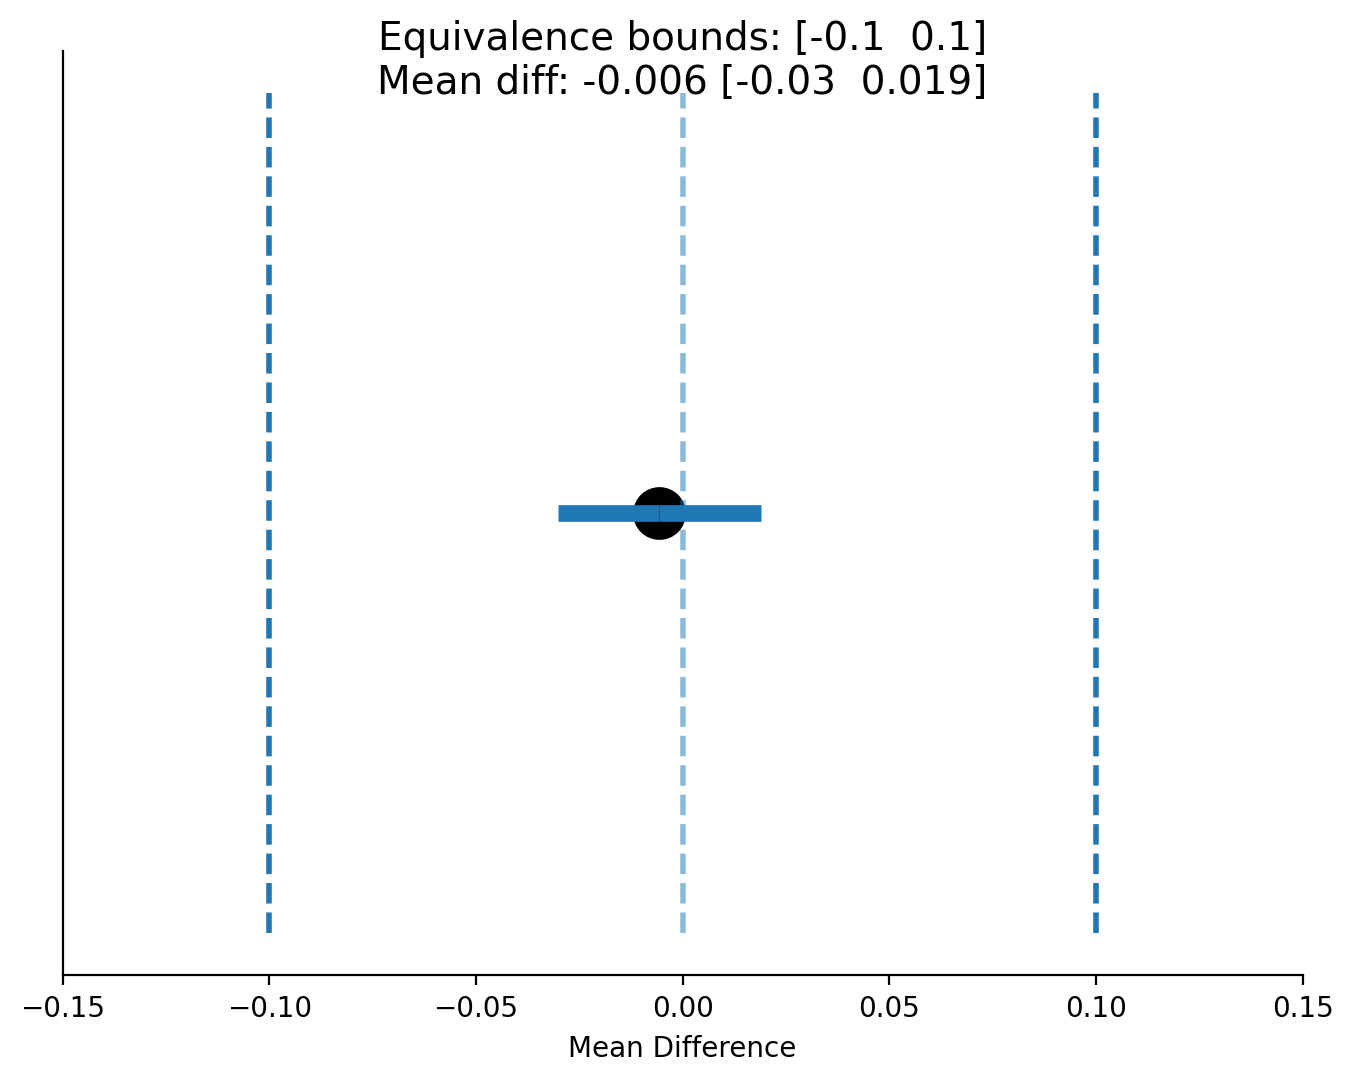

In [9]:
# Import stats function
from pymer4.stats import tost_equivalence

# Generate some data
lower, upper = -0.1, 0.1
x, y = np.random.normal(0.145, 0.025, 35), np.random.normal(0.16, 0.05, 17)
result = tost_equivalence(x, y, lower, upper, plot=True)
# Print the results dictionary nicely
for k, v in result.items():
    print(f"{k}: {v}\n")